# Проект: Рынок заведений общественного питания в Москве

* Автор: Филимонова Мария
* Дата: 30.01.2026

### Цели и задачи проекта

**Цель:** Провести исследовательский анализ данных заведений общественного питания Москвы с выявлением закономерностей в ценообразовании и влияния локации на средний чек.

**Задачи:**

- Загрузить данные из предоставленных источников и провести первичное знакомство с их структурой и качеством.

- Провести предобработку данных для обеспечения корректности анализа: обработать пропуски, дубликаты и преобразовать типы данных.

- Провести исследовательский анализ данных

- Подготовить выводы и рекомендации на основе проведённого анализа, сопроводив результаты наглядными визуализациями.

### Описание данных

Данные состоят из двух датасетов:

- `rest_info.csv` - содержит информацию о заведениях общественного питания
- `rest_price.csv` - содержит информацию о среднем чеке в заведениях общественного питания

Описание датасета `rest_info.csv`:

- `name` — название заведения;
- `address` — адрес заведения;
- `district` — административный район, в котором находится заведение;
- `category` — атегория заведения;
- `hours` — информация о днях и часах работы;
- `rating` —  рейтинг заведения по оценкам пользователей в Яндекс Картах;
- `chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым;
- `seats` — количество посадочных мест.

Описание датасета `rest_price.csv`:

- `price` — категория цен в заведении;
- `avg_bill` — строка, которая хранит среднюю стоимость заказа в виде диапазона;
- `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Средний счёт»;
- `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Цена одной чашки капучино».

### Содержимое проекта

1. Загрузка даных и знакомство с ними
2. Предобработка данных
3. Исследовательский анализ данных
4. Итоговый вывод и рекомендации

## 1. Загрузка даных и знакомство с ними

In [1]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

In [2]:
# Выгружаем данные в переменную rest_info
try:
    rest_info = pd.read_csv('/datasets/rest_info.csv')
except FileNotFoundError:
    rest_info = pd.read_csv('C:/Users/Huawei/OneDrive/Рабочий стол/Проекты/Рынок общественного питания/rest_info.csv')

In [3]:
# Выгружаем данные в переменную rest_price
try:
    rest_price = pd.read_csv('/datasets/rest_price.csv')
except FileNotFoundError:
    rest_price = pd.read_csv('C:/Users/Huawei/OneDrive/Рабочий стол/Проекты/Рынок общественного питания/rest_price.csv')

Познакомимся с данными датасета `rest_info.csv` — выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [4]:
# Выводим первые строки датафрейма на экран
rest_info.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [5]:
# Выводим информацию о датафрейме
rest_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


Датасет `rest_info.csv` содержит 9 столбцов и 8406 строк, в котором представлена информация о заведениях общественного питания

После первичного анализа данных можно сделать следующие выводы:

- Названия столбцов написаны в одном стиле (предположительнго в стиле snake case)

- Большинство представленных данных хранятся в типе данных `object`. Столбцы `category` и `district` необходимо преобразовать в тип данных `category`

- Значения в столбцах `rating` и `seats` имеют тип данных `float64`. Тип данных столбца `seats` необходимо преобразовать в целочисленный тип данных 

- Значение в столбце `chain` имеет тип данных `int64`. Данное значение показывает, является ли заведение сетевым и содержит значения 1 или 0 - размерность этого столбца можно оптимизировать

- Пропуски содержаться в столбцах `hours` и `seats`. Но следует проверить и другие столбцы: в них могут встречаться значения-индикаторы, которые будут говорить об отсутствии данных.

Теперь познакомимся с данными датасета `rest_price.csv`.

In [6]:
# Выводим первые строки датафрейма на экран
rest_price.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [7]:
# Выводим информацию о датафрейме
rest_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


Датасет `rest_price.csv` содержит 5 столбцов и 4058 строк, в котором представлена информация о среднем чеке в заведениях общественного питания
После первичного анализа данных можно сделать следующие выводы:

- Названия столбцов написаны в одном стиле (предположительнго в стиле snake case)

- Большинство представленных данных хранятся в типе данных `object`. Столбец `price` необходимо преобразовать в тип данных `category`

- Значения в столбцах `middle_avg_bill` и `middle_coffe_cup` имеют тип данных `float64`

- Пропуски содержаться во всех столбцах, кроме столбца `id`

### 1.2. Подготовка единого датафрейма

In [8]:
# Объединяем данные
df = rest_info.merge(rest_price, how='left', on='id')

In [9]:
# Выводим первые строки датафрейма на экран
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


In [10]:
# Выводим информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 853.9+ KB


Объединение двух источников данных (rest_info и rest_price) прошло успешно, в результате создан единый датафрейм для дальнейшего анализа. 

Промежуточные выводы:

- В результате операции слияния (merge) по ключевому полю id создан рабочий датафрейм df, содержащий 8406 записей и 13 столбцов. Все записи из основного файла rest_info сохранены (операция how='left'), к ним добавлена информация о ценах.

- Анализ выявил большие объемы пропущенных значений. 

## 2. Предобработка данных

### 2.1 Типы данных

In [11]:
# Выводим информацию о типах данных в датафрейме
df.dtypes

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float64
chain                  int64
seats                float64
price                 object
avg_bill              object
middle_avg_bill      float64
middle_coffee_cup    float64
dtype: object

Из полученных данных видим, что:

- в основном все типы данных корректны

- столбцы `category`, `price` и `district` можно привести к категориальному типу данных

- у столбца `chain` можно понизить размерность

- столбец `seats` необходимо привести к целочисленному типу данных

In [12]:
# Преобразуем столбцы в категориальный тип данных
for coll in ['category', 'price', 'district']:
    df[coll] = df[coll].astype('category')

In [13]:
# Преобразуем в целочисленный тип данных с понижением размерности
for coll in ['chain', 'seats']:
    df[coll] = pd.to_numeric(df[coll], downcast='integer')

In [14]:
# Выводим информацию о типах данных в датафрейме после преобразования
df.dtypes

id                     object
name                   object
category             category
address                object
district             category
hours                  object
rating                float64
chain                    int8
seats                 float64
price                category
avg_bill               object
middle_avg_bill       float64
middle_coffee_cup     float64
dtype: object

### 2.2. Наличие пропусков в данных

In [15]:
# Выводим количество пропущенных строк в датафрейме
df.isna().sum().sort_values(ascending=False)

middle_coffee_cup    7871
middle_avg_bill      5257
price                5091
avg_bill             4590
seats                3611
hours                 536
district                0
category                0
name                    0
id                      0
address                 0
chain                   0
rating                  0
dtype: int64

In [16]:
# Подсчитываем процент строк с пропусками
(df.isna().sum() / len(df) * 100).sort_values(ascending=False)

middle_coffee_cup    93.635498
middle_avg_bill      62.538663
price                60.563883
avg_bill             54.603854
seats                42.957411
hours                 6.376398
district              0.000000
category              0.000000
name                  0.000000
id                    0.000000
address               0.000000
chain                 0.000000
rating                0.000000
dtype: float64

В данных наблюдаются пропуски в следующих столбцах:

- `middlee_coffe_cup`: в 7871 строках (94% данных) отсутствует информация о цене чашки капучино. Возможно, заведение не является кофейней, не указало цену на кофе или это техническая ошибка.
- `middle_avg_bill`: в 5257 строках (63% данных) отсутствует информация о среднем чеке. Возможно, заведение не указало средний чек в своем профиле, данные не были собраны или это техническая ошибка.
- `price`: в 5091 строках (61% данных) отсутсвует информация о ценовой категории. Возможно, заведение не указало ценовую категорию или это техническая ошибка.
- `avg_bill`: в 4590 строках (55% данных) отсутствует информация о средней стоимости заказа. Возможно, заведение не заполнила данные 
- `seats`: в 3611 строках (43% данных) отсутствует информация о количестве посадочных мест. Возможно, заведение не имеет посадочных мест или данные не были заполнены
- `hours`: в 536 строках (6% данных) отсутствует информация о днях и часах работы. Возможно, заведение временно закрыто, имеет нерегулярный график или информация не была обновлена.

**Обработка пропущенных значений**

- Для пропусков в столбце `price` создадим отдельную категорию 'не указана'

- Пропуски в столбце `hours` оставим. Создадим столбец-признак `is_hours`

- Для пропусков в столбце `seats` создадим столбец-признак и заполним пропуски медианой

- Пропуски в толбце `middle_avg_bill` заполним медианой

- Пропуски в столбце `avg_bill` заполнять не будем, так как столбец имеет строковый тип данных и частично информация представлена в числовых столбцах `middle_coffee_cup` и `middle_avg_bill`

**Обработка пропусков в колонкe `price`**

In [17]:
# Выводим уникальные значения в колонке 'price'
price_unique = df['price'].unique()
display(price_unique)

# В результате видим, что пропущенные значения представлены только 'Nan'

[NaN, 'выше среднего', 'средние', 'высокие', 'низкие']
Categories (4, object): ['высокие', 'выше среднего', 'низкие', 'средние']

In [18]:
# Удаляем лишние пробелы в начале и конце строк
df['price'] = df['price'].str.strip()

In [19]:
# Заменяем пропуски 'Nan' значением 'не указана'
replacement = 'не указака'
df['price'] = df['price'].fillna(replacement)

In [20]:
# Выводим уникальные значения в колонке 'price' после обработки пропущенных значений
rating_unique = df['price'].unique()
display(rating_unique)

array(['не указака', 'выше среднего', 'средние', 'высокие', 'низкие'],
      dtype=object)

**Обработка пропусков в колонкe `hours`**

In [21]:
# Напишем функцию для создания столбцов-признаков
def create_is_na(value):
    if value:
        return 0
    else:
        return 1
    
# Создаём столбец is_hours с помощью функции create_is_na
df['is_hours'] = df['hours'].isna().apply(create_is_na)

**Обработка пропусков в колонкe `seats`**

In [22]:
# Обработка пропусков в столбце seats
def pass_proccesing_1(df, seats):
    # Медиана по категории
    category_median = df.groupby('category')[seats].median()
    # Общая медиана по столбцу seats
    seats_median = df[seats].median()
    
    def staff_row_1(row):
        # Если значение не пропущено, возвращаем его
        if not pd.isna(row[seats]):
            return row[seats]
        
        # Получаем значение по категории для текущей строки
        category_value = row['category']

        # Если значение в категории не пропущено
        if not pd.isna(category_value):
            median_value = category_median.loc[(category_value)]
            if not pd.isna(median_value):
                return median_value
            
        # Возвращаем общую медиану
        return seats_median
    
    # Прменяем функцию к датафрейму
    df[seats] = df.apply(staff_row_1, axis=1)
    return df


df = pass_proccesing_1(df, 'seats')

C:\Users\Huawei\AppData\Local\Temp\ipykernel_12416\558907624.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_median = df.groupby('category')[seats].median()


**Обработка пропусков в колонкe `middle_avg_bill`**

In [23]:
# Обработка пропусков в столбце middle_avg_bill
def pass_proccesing_2(df, middle_avg_bill):
    # Медиана по категории
    category_median = df.groupby('category')[middle_avg_bill].median()
    # Общая медиана по столбцу middle_avg_bill
    middle_avg_bill_median = df[middle_avg_bill].median()
    
    def staff_row_2(row):
        # Если значение не пропущено, возвращаем его
        if not pd.isna(row[middle_avg_bill]):
            return row[middle_avg_bill]
        
        # Получаем значение по категории для текущей строки
        category_value = row['category']

        # Если значение в категории не пропущено
        if not pd.isna(category_value):
            median_value = category_median.loc[(category_value)]
            if not pd.isna(median_value):
                return median_value
            
        # Возвращаем общую медиану
        return middle_avg_bill_median
    
    # Прменяем функцию к датафрейму
    df[middle_avg_bill] = df.apply(staff_row_2, axis=1)
    return df


df = pass_proccesing_2(df, 'middle_avg_bill')

C:\Users\Huawei\AppData\Local\Temp\ipykernel_12416\2563865452.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_median = df.groupby('category')[middle_avg_bill].median()


Проверим то, как заполнены пропуски. Выведем информацию о датафрейме

In [24]:
# Выводим информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   id                 8406 non-null   object  
 1   name               8406 non-null   object  
 2   category           8406 non-null   category
 3   address            8406 non-null   object  
 4   district           8406 non-null   category
 5   hours              7870 non-null   object  
 6   rating             8406 non-null   float64 
 7   chain              8406 non-null   int8    
 8   seats              8406 non-null   float64 
 9   price              8406 non-null   object  
 10  avg_bill           3816 non-null   object  
 11  middle_avg_bill    8406 non-null   float64 
 12  middle_coffee_cup  535 non-null    float64 
 13  is_hours           8406 non-null   int64   
dtypes: category(2), float64(4), int64(1), int8(1), object(6)
memory usage: 747.9+ KB


### 2.3 Явные и неявнфе дубликаты

In [25]:
# Проверяем полные дубликаты в датафрейме 
df.duplicated().sum()

np.int64(0)

В значениях нет явных дубликатов

Проверим неявные дубликаты по значением `name` и `address`:

In [26]:
# Создаем функцию для поиска неявныз дубликатов в name и address (name+address)
def name_address_duplicated(df):
    # Создадим функцию для нормализации данных
    def normalize_text(text):
        return str(text).lower().strip()
    
    # Создадим новые столбцы с нормализованными данными
    df['name_normalized'] = df['name'].apply(normalize_text)
    df['address_normalizes'] = df['address'].apply(normalize_text)

    # Объединим нормализованные данные
    df['column_join'] = df['name_normalized'] + ' | ' + df['address_normalizes']

    # Посчитаем уникальные значения
    original_count = df[['name', 'address']].drop_duplicates().shape[0]
    normalized_count = df[['name_normalized', 'address_normalizes']].drop_duplicates().shape[0]

    # Выводим количество уникальных пар до и после нормализации
    print(f'Оригинальных уникальных пар: {original_count}')
    print(f'Нормализованных уникальных пар: {normalized_count}')
    print()

    # Проверим, есть ли неявные дубликаты
    if original_count > normalized_count:
        res = original_count - normalized_count
        print(f'Найдено {res} неявных дубликатов по названию и адресу')
        print()

        column_join_counts = df['column_join'].value_counts()
        duplicates = column_join_counts[column_join_counts > 1]

    num_group = 1

    # Перебираем каждый дубликат
    for value, count in duplicates.items():

        print(f'{num_group}. Пример дубликатов')
    
        # Выводим нормализованное значение
        print(f'После нормализации: {value}')
    
        # Выводим сколько раз встретился
        print(f'Найдено {count} записей с этим значением')
        print()
    
        # Находим все строки с таким значением
        rows_with_this_key = df[df['column_join'] == value]
    
        # Выводим оригинальные названия и адреса
        print('Оригинальные данные:')
    
        for index, row_data in rows_with_this_key.iterrows():
            print(f"Название: {row_data['name']}")
            print(f"Адрес: {row_data['address']}")
            print()
            break

        num_group += 1
    
result = name_address_duplicated(df)

Оригинальных уникальных пар: 8406
Нормализованных уникальных пар: 8402

Найдено 4 неявных дубликатов по названию и адресу

1. Пример дубликатов
После нормализации: раковарня клешни и хвосты | москва, проспект мира, 118
Найдено 2 записей с этим значением

Оригинальные данные:
Название: Раковарня Клешни и Хвосты
Адрес: Москва, проспект Мира, 118

2. Пример дубликатов
После нормализации: кафе | москва, парк ангарские пруды
Найдено 2 записей с этим значением

Оригинальные данные:
Название: Кафе
Адрес: Москва, парк Ангарские Пруды

3. Пример дубликатов
После нормализации: more poke | москва, волоколамское шоссе, 11, стр. 2
Найдено 2 записей с этим значением

Оригинальные данные:
Название: More poke
Адрес: Москва, Волоколамское шоссе, 11, стр. 2

4. Пример дубликатов
После нормализации: хлеб да выпечка | москва, ярцевская улица, 19
Найдено 2 записей с этим значением

Оригинальные данные:
Название: Хлеб да Выпечка
Адрес: Москва, Ярцевская улица, 19



После проведении проверки на неявные дубликаты по комбинации полей 'name' и 'address' можно сделать следующие выводы:

- Оригинальных пар 8406

- Нормализованныз пар: 8402

- Это означает, что в данных есть 4 неявных дубликата, которые после нормализации становятся одинаковыми

Удалим неявные дубликаты

In [27]:
# Создаем функцию для удаления неявных дубликатов
def drop_duplicates(df):
    
    # Нормализация текста
    def normalize_text(text):
        return str(text).lower().strip()
    
    df_clean = df.copy()

    # Создадим новые столбцы с нормализованными данными
    df_clean['name_normalized'] = df_clean['name'].apply(normalize_text)
    df_clean['address_normalized'] = df_clean['address'].apply(normalize_text)
    
    # Объединим нормализованные данные
    df_clean['column_join'] = df_clean['name_normalized'] + ' | ' + df_clean['address_normalized']
    
    # Группировка и выбор первой записи из каждой группы
    df_clean = df_clean.drop_duplicates(subset=['column_join'], keep='first')
    
    # Удаление временных столбцов (корректно через drop)
    df_clean = df_clean.drop(['name_normalized', 'address_normalized', 'column_join'], axis=1)
    
    return df_clean

# Применение функции
df = drop_duplicates(df)
print(f"Количество записей после удаления дубликатов: {len(df)}")

Количество записей после удаления дубликатов: 8402


После удления 4 неявных дубликатов, количество уникальных пар составляет 8402. Также были сохранены по одной записи из каждой группы дубликатов

Теперь проверим корректность написания категориальных значений в данных

In [28]:
# Проверяем уникальные значения в категориальных столбцах
for column in ['category', 'district', 'price']:
    print(f'Уникальные значения в столбце {column}:')
    print(df[column].sort_values().unique())
    print()

Уникальные значения в столбце category:
['бар,паб', 'булочная', 'быстрое питание', 'кафе', 'кофейня', 'пиццерия', 'ресторан', 'столовая']
Categories (8, object): ['бар,паб', 'булочная', 'быстрое питание', 'кафе', 'кофейня', 'пиццерия', 'ресторан', 'столовая']

Уникальные значения в столбце district:
['Восточный административный округ', 'Западный административный округ', 'Северный административный округ', 'Северо-Восточный административный округ', 'Северо-Западный административный округ', 'Центральный административный округ', 'Юго-Восточный административный округ', 'Юго-Западный административный округ', 'Южный административный округ']
Categories (9, object): ['Восточный административный округ', 'Западный административный округ', 'Северный административный округ', 'Северо-Восточный административный округ', ..., 'Центральный административный округ', 'Юго-Восточный административный округ', 'Юго-Западный административный округ', 'Южный административный округ']

Уникальные значения в столбце

В выводимых данных ошибок не наблюдается

### 2.4 Создание столбца is_24_7

In [29]:
# Создаем функцию для создания нового столбца is_24_7
def categories_hours(hours):
    # Проверяем, есть ли пропущенные значения
    if pd.isna(hours):
        return False
    
    # Приводим к строке и нижнему регистру
    hours_str = str(hours).lower()

    # Проверяем условие
    if 'ежедневно' in hours_str and 'круглосуточно' in hours_str:
        return True
    else:
        return False

# Создаем новый столбец
df['is_24_7'] = df['hours'].apply(categories_hours)


In [30]:
# Выводим первые 20 значений нового столбца
df['is_24_7'].head(20)

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10     True
11    False
12    False
13    False
14    False
15    False
16    False
17     True
18    False
19     True
Name: is_24_7, dtype: bool

### 2.5 Промежуточные выводы

В результате предобработки данных были выполнены следующие действия:

- Столбцы `category`, `price` и `district` были приведены к категориальному типу данных. 

- У столбца `chain` была понижена размерность. А столбец `seats` был приведен к целочисленному типу данных

- Пропуски были обнаружены в таких столбцах, как `middle_avg_bill`, `middle_coffee_cup`, `price`, `avg_bill`, `seats` и `hours`:
    - Для пропусков в столбце `price` была создана отдельная категория "Не указана";

    - Пропуски в столбце `hours` были оставлены, но был создан столбец-признак `is_hours`;

    - Для столбца `seats` был такде создан столбец-признак, а пропущенные значения были заполнены медианой;

    - Пропуски в столбце `middle_avg_bill` были заполнены медианой;

    - Пропуски в столбцах `middle_coffee_cup` не были заполнены, также как и пропуски в столбце `avg_bill`

- В данных не было обнаружено явных дубликатов. 

- Неявные дубликаты были обнаружены только при "сочетании" столбцов `name` и `address` (`name` + `address`). 

- Также в категориальных значений ошибок нет

- Был создан столбец `is_24_7`

## 3. Исследовательский анализ данных

### 3.1. Задача 1

In [31]:
# Выведем уникальные значения столбца category
df['category'].unique()

['кафе', 'ресторан', 'кофейня', 'пиццерия', 'бар,паб', 'быстрое питание', 'булочная', 'столовая']
Categories (8, object): ['бар,паб', 'булочная', 'быстрое питание', 'кафе', 'кофейня', 'пиццерия', 'ресторан', 'столовая']

В данных представлены следующие категории заведений:

- кафе,
- ресторан,
- кофейня,
- пиццерия,
- бар, паб,
- быстрое питание,
- булочная,
- столовая.

In [32]:
# Подсчитаем количество заведений в каждой категории:
df.groupby('category')['category'].count().sort_values(ascending=False)

C:\Users\Huawei\AppData\Local\Temp\ipykernel_12416\3248882109.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('category')['category'].count().sort_values(ascending=False)


category
кафе               2376
ресторан           2042
кофейня            1413
бар,паб             764
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: category, dtype: int64

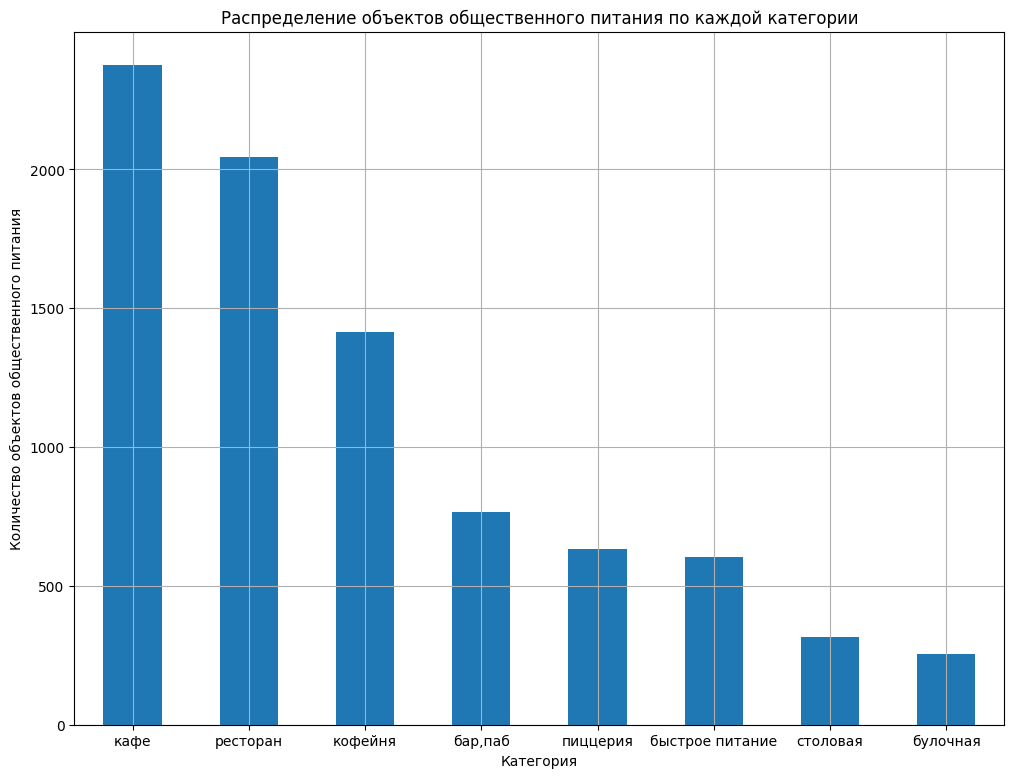

In [33]:
# Задаем размер графика
plt.figure(figsize = (12, 9))

# Строим столбчатую диаграмму
df['category'].value_counts(ascending=False).plot(
    kind='bar',
    rot=0,
    legend=False
)

# Настраиваем оформление графика
plt.title('Распределение объектов общественного питания по каждой категории')
plt.xlabel('Категория')
plt.ylabel('Количество объектов общественного питания')

# Добавляем сетку графика
plt.grid()

# Выводим визуализированные данные
plt.show()

**Вывод:**

- Наиболее популярными являются кафе (2378), рестораны (2043) и кофейни (1413)

- Наименее популярными являются столовая (315) и булочная (256)

In [34]:
# Подсчитываем количество заведений по категориям
categories_count = df['category'].value_counts().sort_values(ascending=False)

# Вычисляем общее количество заведений
categoris_sum = categories_count.sum()

# Рассчитываем доли каждой категории в процентах
category_part = (categories_count / categoris_sum) * 100

# Выводим результаты
print("Доля каждой категории в общем количестве заведений (в %):")
print(category_part.round(2))

Доля каждой категории в общем количестве заведений (в %):
category
кафе               28.28
ресторан           24.30
кофейня            16.82
бар,паб             9.09
пиццерия            7.53
быстрое питание     7.18
столовая            3.75
булочная            3.05
Name: count, dtype: float64


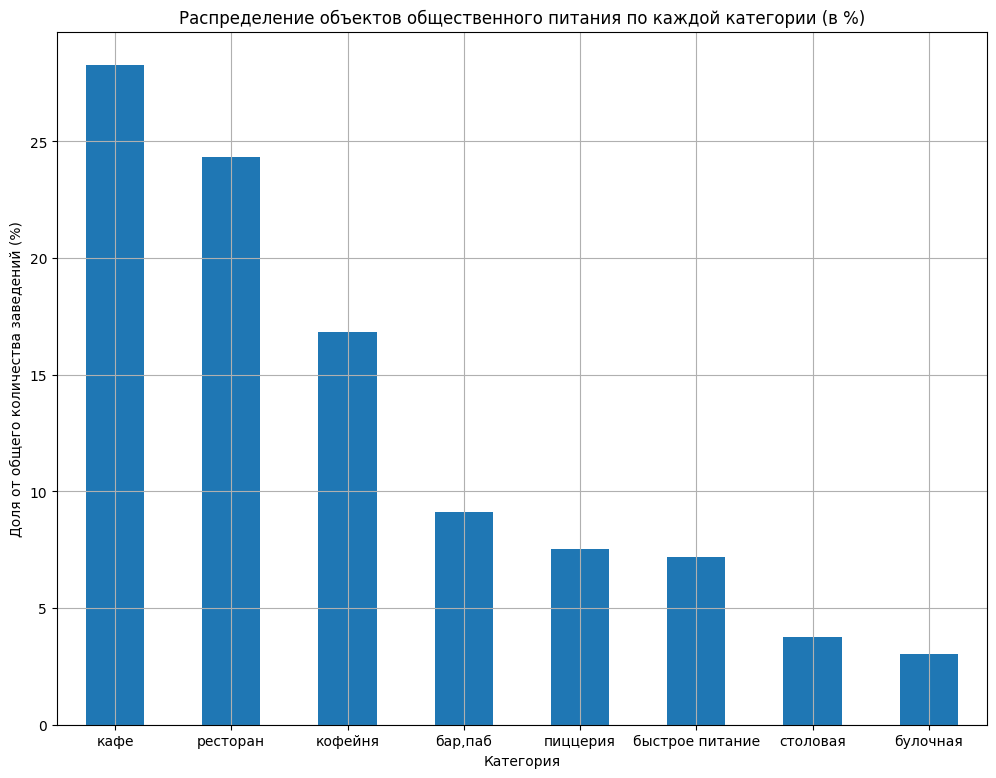

In [35]:
# Задаем размер графика
plt.figure(figsize = (12, 9))

# Строим столбчатую диаграмму
category_part.plot(
    kind='bar',
    rot=0,
    legend=False
)

# Настраиваем оформление графика
plt.title('Распределение объектов общественного питания по каждой категории (в %)')
plt.xlabel('Категория')
plt.ylabel('Доля от общего количества заведений (%)')

# Добавляем сетку графика
plt.grid()

# Выводим визуализированные данные
plt.show()

**Вывод:**

- Доля самых популярных заведений: кафе (28,28%), рестораны (24,3%) и кофейни (16,82%)

- Доля менее популярных заведений: столовая (3,75 %) и булочная (3,05 %)

### 3.2. Задача 2

In [36]:
# Выводим уникальные значения столбца district
df['district'].unique()

['Северный административный округ', 'Северо-Восточный административный округ', 'Северо-Западный административный округ', 'Западный административный округ', 'Центральный административный округ', 'Восточный административный округ', 'Юго-Восточный административный округ', 'Южный административный округ', 'Юго-Западный административный округ']
Categories (9, object): ['Восточный административный округ', 'Западный административный округ', 'Северный административный округ', 'Северо-Восточный административный округ', ..., 'Центральный административный округ', 'Юго-Восточный административный округ', 'Юго-Западный административный округ', 'Южный административный округ']

В данных представлены следующие административные районы Москвы:

- Северный одминистративный округ,
- Северо-Восточный административный округ,
- Северо-Западный административный округ,
- Западный административный округ,
- Центральный административный округ,
- Восточный административный округ,
- Юго-Восточный администативный округ,
- Южный административный округ,
- Юго-Западный административный округ.

In [37]:
# Подсчитаем количество заведений в каждом районе:
district_count = df.groupby('district')['district'].count().sort_values(ascending=False)

# Выводим результат
print(district_count)

district
Центральный административный округ         2242
Северный административный округ             898
Южный административный округ                892
Северо-Восточный административный округ     890
Западный административный округ             850
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: district, dtype: int64


C:\Users\Huawei\AppData\Local\Temp\ipykernel_12416\3486310700.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  district_count = df.groupby('district')['district'].count().sort_values(ascending=False)


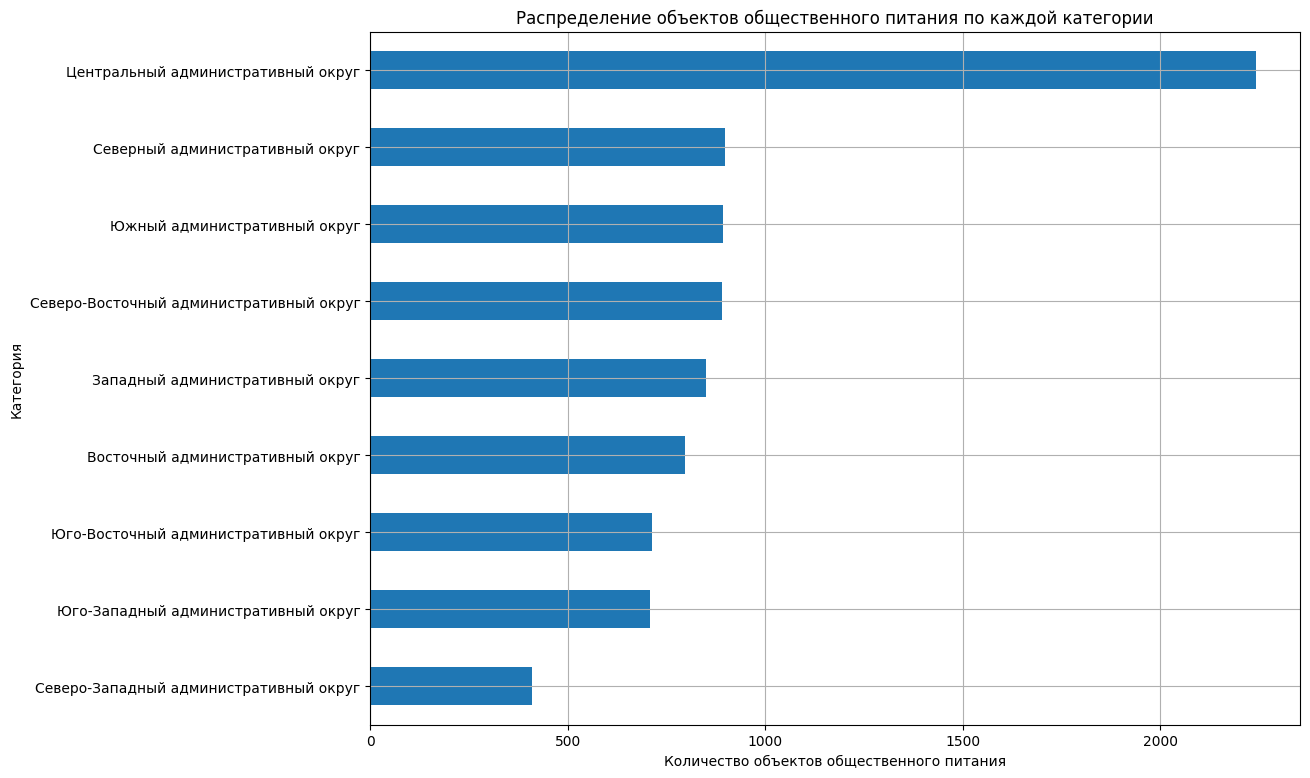

In [38]:
# Задаем размер графика
plt.figure(figsize = (12, 9))

# Создаем столбчатую диаграмму
df['district'].value_counts(ascending=True).plot(
    kind='barh',
    rot=0,
    legend=False
)

# Настраиваем оформление графика
plt.title('Распределение объектов общественного питания по каждой категории')
plt.xlabel('Количество объектов общественного питания')
plt.ylabel('Категория')

# Добавляем сетку графика
plt.grid()

# Выводим визуализированные данные
plt.show()

**Вывод:**

- Наибольшую популярность имеет Центальный административный округ (2242)

- Наименее популярным является Северо-Западный административный округ (409)

In [39]:
# Вычисляем общее количество заведений
district_sum = district_count.sum()

# Рассчитываем доли каждой категории в процентах
district_part = (district_count / district_sum) * 100

# Выводим результаты
print("Доля каждого административного округа в общем количестве заведений (в %):")
print(district_part.round(2))

Доля каждого административного округа в общем количестве заведений (в %):
district
Центральный административный округ         26.68
Северный административный округ            10.69
Южный административный округ               10.62
Северо-Восточный административный округ    10.59
Западный административный округ            10.12
Восточный административный округ            9.50
Юго-Восточный административный округ        8.50
Юго-Западный административный округ         8.44
Северо-Западный административный округ      4.87
Name: district, dtype: float64


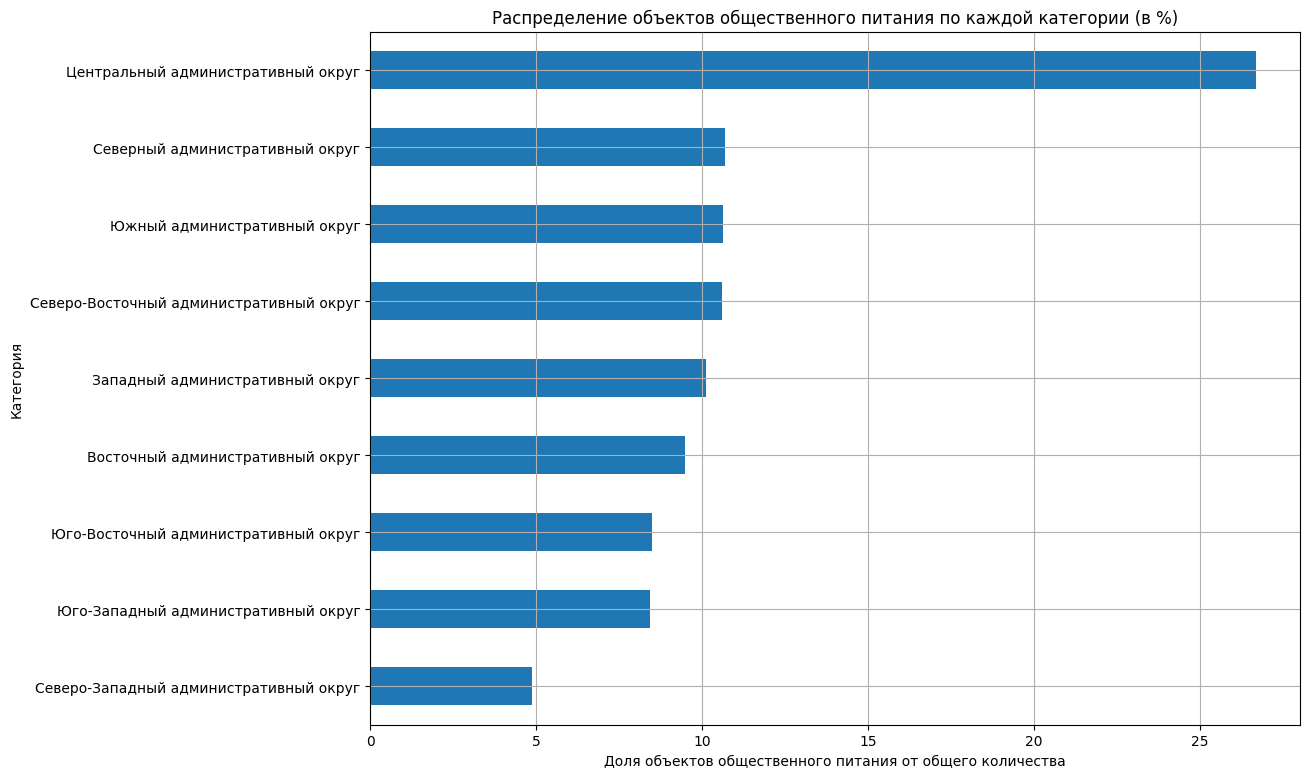

In [40]:
# Задаем размер графика
plt.figure(figsize = (12, 9))

# Создаем столбчатую диаграмму
district_part.sort_values(ascending=True).plot(
    kind='barh',
    rot=0,
    legend=False
)

# Настраиваем оформление графика
plt.title('Распределение объектов общественного питания по каждой категории (в %)')
plt.xlabel('Доля объектов общественного питания от общего количества')
plt.ylabel('Категория')

# Добавляем сетку графика
plt.grid()

# Выводим визуализированные данные
plt.show()

**Вывод:**

- Доля самого популярного администативного округа составляет 26,68 %

- Доля самого непопулярного административного округа составляет 4,87 %

In [41]:
# Фильтруем данные по Центральном административном округе (ЦАО)
df_center = df[df['district'] == 'Центральный административный округ']

In [42]:
# Посчитаем количество заведений по категориям в ЦАО
df_center.groupby('category')['category'].count().sort_values(ascending=False)

C:\Users\Huawei\AppData\Local\Temp\ipykernel_12416\774531647.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_center.groupby('category')['category'].count().sort_values(ascending=False)


category
ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: category, dtype: int64

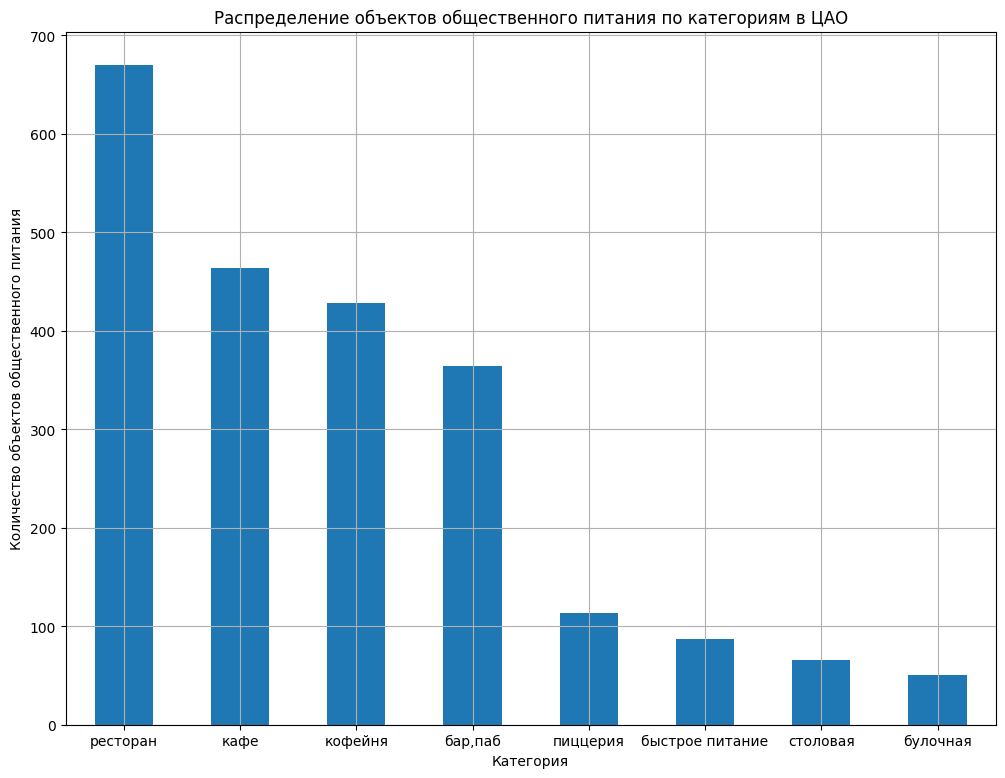

In [43]:
# Группируем по категориям и считаем количество заведений
df_res = df_center['category'].value_counts()

# Задаем размер графика
plt.figure(figsize=(12, 9))

# Создаем горизонтальную столбчатую диаграмму
df_res.plot(
    kind='bar',
    rot=0,
    legend=False
)

# Настраиваем оформление графика
plt.title('Распределение объектов общественного питания по категориям в ЦАО')
plt.xlabel('Категория')
plt.ylabel('Количество объектов общественного питания')

# Добавляем сетку шрафика
plt.grid()

# Выводим визуализированные данные
plt.show()

**Вывод:**

- В Центрально административном окруне наиболее популярны рестораны (670), кафе(464) и кофейни(428)

- Наименее популярными являются столовая (66) и булочная (50)

### 3.3. Задача 3

In [44]:
# Посчитаем количество сетевых и несетевых заведений
df_chain = df['chain'].value_counts()

# Посчитаем доли сетевых и несетевых заведений
total_chain_1 = (df_chain[1] / len(df) * 100).round(2)
total_chain_2 = (df_chain[0] / len(df) * 100).round(2)

# Выводим результат
print("Общее распределение:")
print(f'Сетевые: {df_chain[1]} ({total_chain_1} %)')
print(f'Несетевые: {df_chain[0]} ({total_chain_2} %)')

Общее распределение:
Сетевые: 3203 (38.12 %)
Несетевые: 5199 (61.88 %)


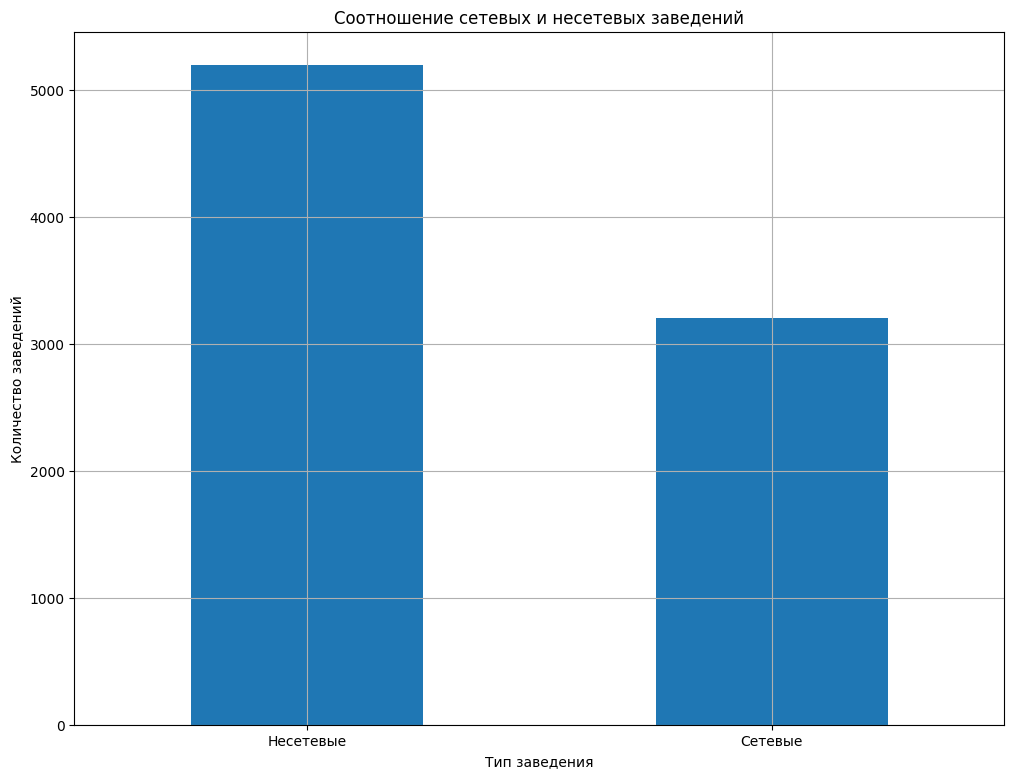

In [45]:
# Задаем размер графика
plt.figure(figsize=(12, 9))

# Создаем столбчатую диаграмму
df_chain.plot(
    kind='bar',
    rot=0,
    legend=False
)

# Меняем подписи на оси X
plt.xticks([0, 1], ['Несетевые', 'Сетевые'])

# Задаем названия для осей
plt.title('Соотношение сетевых и несетевых заведений')
plt.xlabel('Тип заведения')
plt.ylabel('Количество заведений')

# Настраиваем сетку
plt.grid()

# Выводим визуализированные данные
plt.show()

**Вывод:**

- В результате видим, что несетевых заведений больше чем сетевых, примерно, в 1,5 раза

<Figure size 1200x900 with 0 Axes>

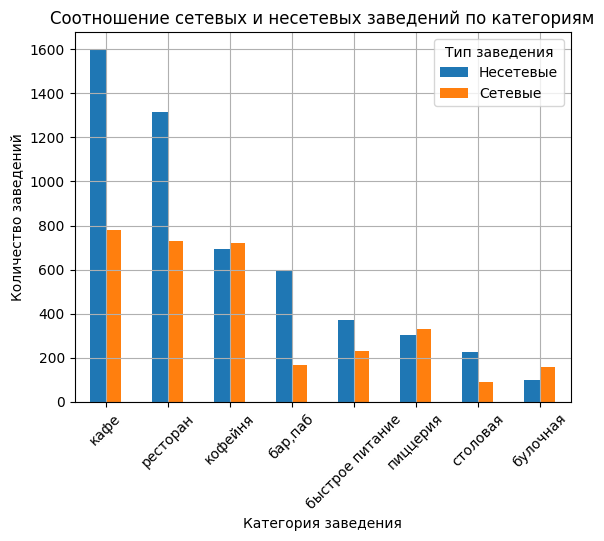

In [46]:
# Разднлим данные на две группы 
chain_0 = df[df['chain'] == 0]
chain_1 = df[df['chain'] == 1]

# Посчитаем количество заведений по категориям для каждой группы
chain_0_count = chain_0['category'].value_counts()
chain_1_count = chain_1['category'].value_counts()

# Соединим полученные данные
df_chain = pd.concat([chain_0_count, chain_1_count], axis=1)

# Поменяем название стобцов
df_chain.columns = ['Несетевые', 'Сетевые']

# Заполняем 0 значения Nan
df_chain = df_chain.fillna(0)

# Задаем размер графика
plt.figure(figsize=(12, 9))

# Создаем столбчатую диаграмму
df_chain.sort_values(by='Несетевые', ascending=False).plot(
    kind='bar',
    rot=45,
    title='Соотношение сетевых и несетевых заведений по категориям'
)

# Задаем название для осей и легенду
plt.xlabel('Категория заведения')
plt.ylabel('Количество заведений')
plt.legend(title='Тип заведения')

# Настраиваем сетку графика
plt.grid()

# Выводим визуализированные данные
plt.show()

**Вывод:**

- Из графика видим, что такие категории, как кафе, ресторан, бар, паб, быстрое питание и столовая являются в большей степени несетевыми заведениями, хотя и сетевые заведения из приведенных категорий есть

- А такие категории как, кофейни, пиццерии и булочные почти в равных количествах могут быть и сетевыми и несетевыми

<Figure size 1200x900 with 0 Axes>

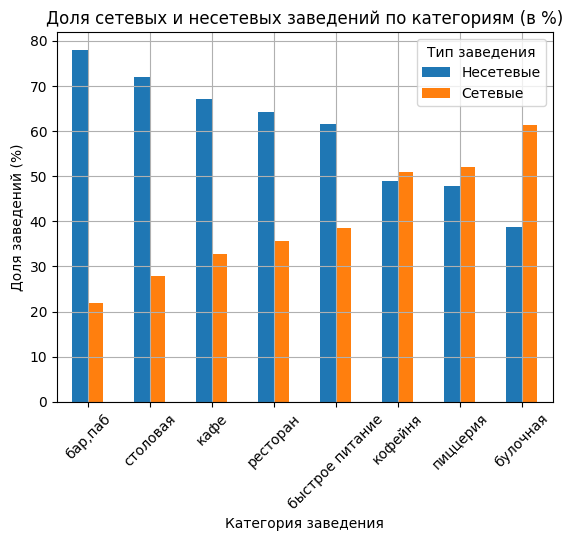

In [47]:
# Рассчитываем долю (в %) для каждой категории
total_per_category = df_chain.sum(axis=1)
df_chain_part = df_chain.div(total_per_category, axis=0) * 100

# Задаем размер графика
plt.figure(figsize=(12, 9))

# Создаем столбчатую диаграмму
df_chain_part.sort_values(by='Несетевые', ascending=False).plot(
    kind='bar',
    rot=45,
    title='Доля сетевых и несетевых заведений по категориям (в %)'
)

# Задаем название для осей и легенду
plt.xlabel('Категория заведения')
plt.ylabel('Доля заведений (%)')
plt.legend(title='Тип заведения')

# Настраиваем сетку графика
plt.grid()

# Выводим визуализированные данные
plt.show()

**Вывод:**

- Наибольшая доля несетевых заведений наблюдается в таких категориях, как бар, паб (78-80 %) и столовая (около 70-72 %)

- Наибольшая доля сетевых заведений наблюдается у булочной (около 60-62 %) и пиццерий (около 50-52 %)

### 3.4. Задача 4

In [48]:
# Выведем основные статистические показатели по столбцу seats:
print("Описательная статистика по количеству посадочных мест:")
print(df['seats'].describe())


Описательная статистика по количеству посадочных мест:
count    8402.000000
mean       92.524280
std        94.870205
min         0.000000
25%        55.000000
50%        75.500000
75%        86.000000
max      1288.000000
Name: seats, dtype: float64


**Вывод:**

- Из полученных данных видно, что среднее значение сильно выше медианы — явный признак правосторонней асимметрии. Это типично для таких показателей: большинство заведений небольшие, но есть и крупные, которые тянут среднее вверх.

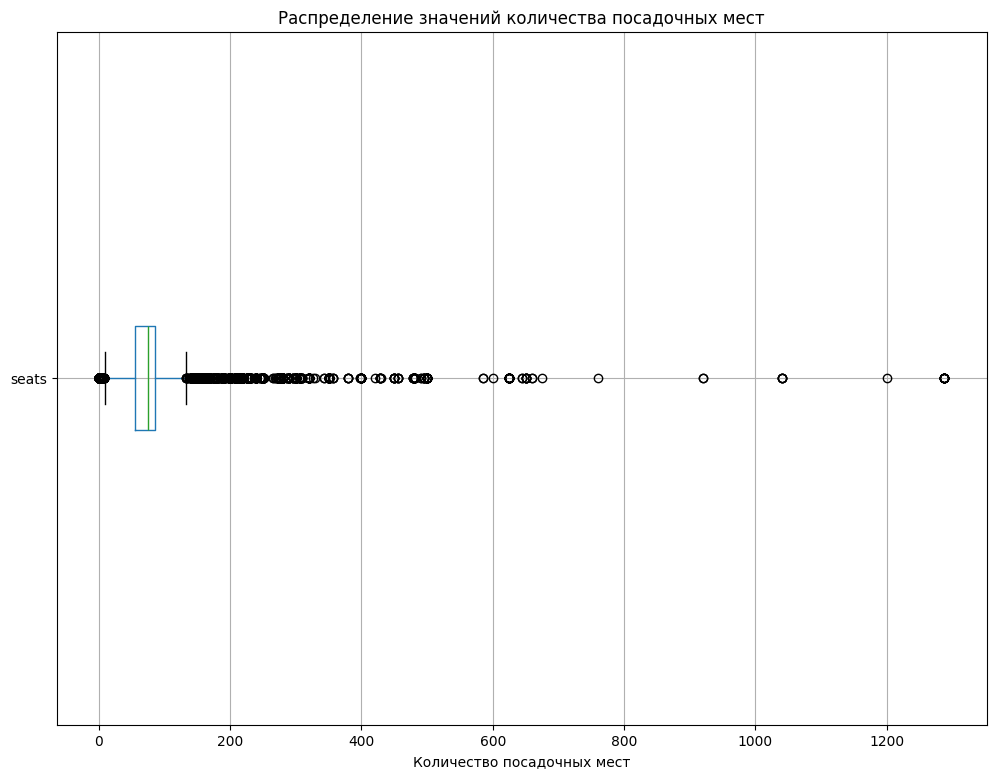

In [49]:
# Задаем размер графика
plt.figure(figsize=(12, 9))

# Строим график "ящик с усами"
df.boxplot(column='seats',
           vert=False,
           grid=True
           )

# Настраиваем оформление графика
plt.title('Распределение значений количества посадочных мест')
plt.xlabel('Количество посадочных мест')

# Выводим график
plt.show()

In [50]:
# Вычисляем квартили
Q1 = df['seats'].quantile(0.25)
Q3 = df['seats'].quantile(0.75)

# Вычисляем межквартильный размах
IQR = Q3 - Q1

# Определяем границы выбросов
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Фильтруем выбросы
outliers = df[(df['seats'] < lower_bound) | (df['seats'] > upper_bound)]

# Выводи результат
print(f"Количество выбросов: {len(outliers)}")
print("Примеры выбросов:")
print(outliers[['name', 'category', 'seats']].head(10))


Количество выбросов: 1491
Примеры выбросов:
              name         category  seats
1   Четыре комнаты         ресторан    4.0
4        Иль Марко         пиццерия  148.0
13         Буханка         булочная  180.0
15       Дом обеда         столовая  180.0
20  Чебуреки Манты             кафе  148.0
27     Шаурму Х@чу  быстрое питание    4.0
34  Домино'с Пицца         пиццерия  247.0
44       Кафетерий             кафе    8.0
48        БлинБери         ресторан    4.0
53    Royal Coffee          кофейня  148.0


**Вывод:**

Из визуализированнных данных и расчета по методу межквартильного размаха (IQR) можно прийти к выводу, наличие выводов:

- выявлены заведения с числом мест существенно ниже нижнего порога

- зафиксированы объекты с чрезмерно большим числом мест

Возможные причины выбросов:

- Ошибки ввода данных

- Специфика форматов заведений

In [51]:
# Группировка и расчет основных показателей
category_seats = df.groupby('category')['seats'].agg(['count', 'mean', 'median', 'std']).round(2)
display(category_seats)

C:\Users\Huawei\AppData\Local\Temp\ipykernel_12416\3274189807.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_seats = df.groupby('category')['seats'].agg(['count', 'mean', 'median', 'std']).round(2)


,count,mean,median,std
category,,,,
"бар,паб",764,108.16,82.5,115.28
булочная,256,72.77,50.0,76.69
быстрое питание,603,84.62,65.0,82.77
кафе,2376,79.14,60.0,86.42
кофейня,1413,96.58,80.0,94.46
пиццерия,633,81.64,55.0,94.03
ресторан,2042,108.31,86.0,99.11
столовая,315,88.13,75.5,89.41


C:\Users\Huawei\AppData\Local\Temp\ipykernel_12416\3826440524.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_seats_median = df.groupby('category')['seats'].median().sort_values().index


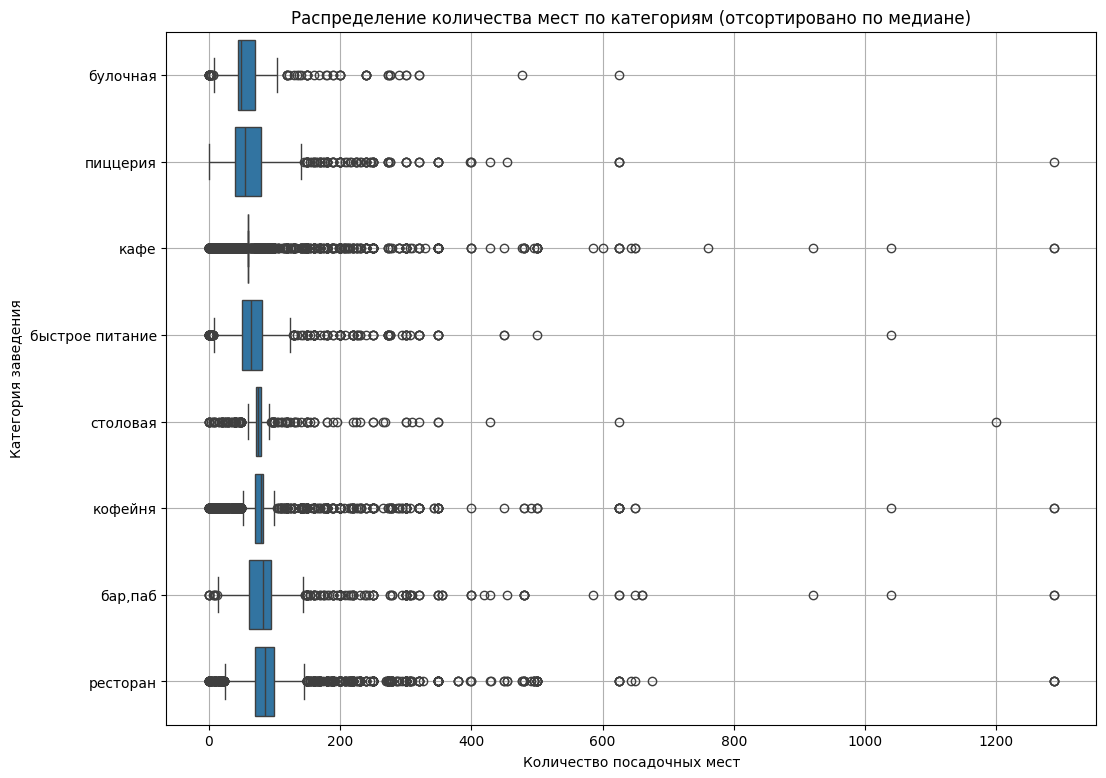

In [52]:
# Группируем данные и считаем медиану
category_seats_median = df.groupby('category')['seats'].median().sort_values().index

# Задаем размер графика
plt.figure(figsize=(12, 9))

# Создаем график "ящик с усами"
sns.boxplot(data=df, 
            x='seats', 
            y='category',
              order = category_seats_median)

# Настраиваем оформление графика
plt.title('Распределение количества мест по категориям (отсортировано по медиане)')
plt.xlabel('Количество посадочных мест')
plt.ylabel('Категория заведения')

# Добавляем сетку графика
plt.grid()

# Выводим визуализированные данные
plt.show()

**Выводы:**

- Рестораны и кафе имеют наибольшее количество посадочных мест (медиана ближе к верхней части шкалы, отдельные точки достигают 1200 мест)

- Булочные, кофейни, столовые — компактные форматы с малым и средним количеством мест (медиана в диапазоне 0–200 мест)

- Пиццерии, бары/пабы занимают промежуточное положение (медиана около 100–200 мест), сочетая элементы как компактного, так и среднего формата.

### 3.5. Задача 5

C:\Users\Huawei\AppData\Local\Temp\ipykernel_12416\2160357891.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_rating = df.groupby('category')['rating'].mean().round(2)


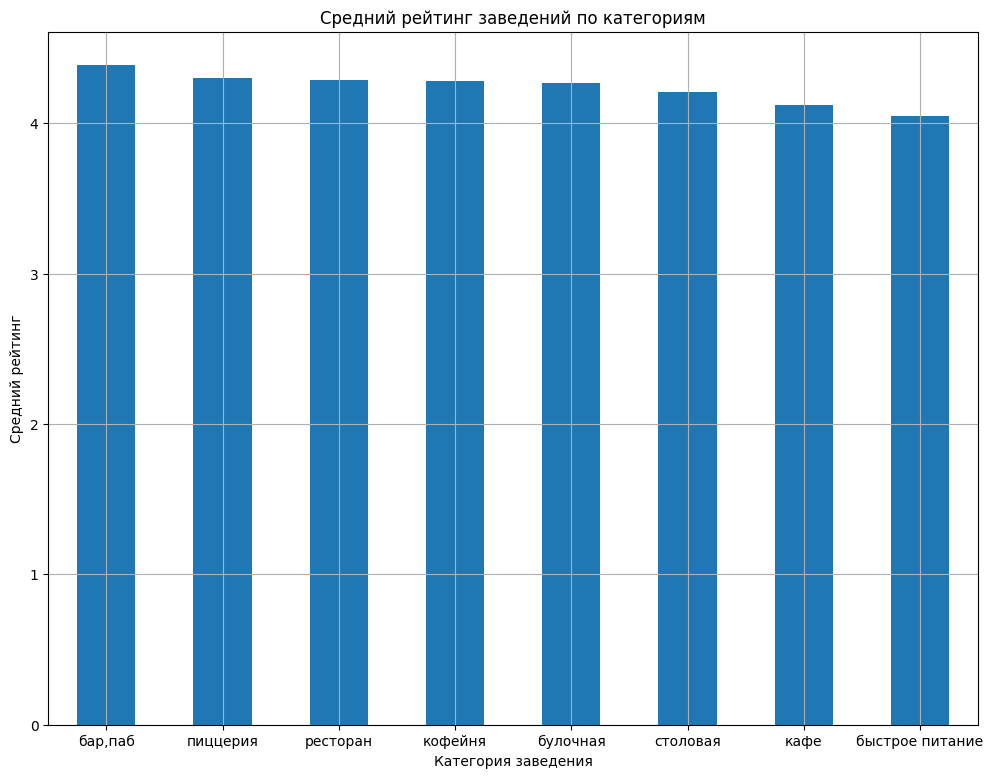

In [53]:
# Вычисляем средний рейтинг по категориям
category_rating = df.groupby('category')['rating'].mean().round(2)

# Сортируем по убыванию рейтинга
category_rating_sorted = category_rating.sort_values(ascending=False)

# Задаем размер графика
plt.figure(figsize=(12, 9))

# Строим столбчатую диаграмму
category_rating_sorted.plot(kind='bar',
                  rot=0,
                  legend=False)

# Настраиваем оформление графика
plt.ylabel('Средний рейтинг')
plt.xlabel('Категория заведения')
plt.title('Средний рейтинг заведений по категориям')

# Настраиваем сетку
plt.grid()

# Выводим визуализированные данные
plt.show()

**Вывод:**

- Средний рейтинг для разных типов общепита не сильно различается

### 3.6. Задача 6

In [54]:
# Вычисляем матрицу корреляции
correlation_matrix = df[['category', 'district', 'chain', 'seats', 'price', 'is_24_7', 'rating']].phik_matrix()

print('Корреляционная матрица с коэффициентом phi_k для переменной rating')
correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

interval columns not set, guessing: ['chain', 'seats', 'rating']
Корреляционная матрица с коэффициентом phi_k для переменной rating


,rating
price,0.281253
district,0.200761
category,0.189716
is_24_7,0.150365
chain,0.107833
seats,0.000000


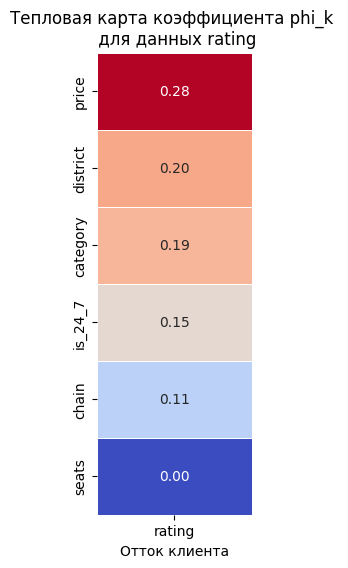

In [55]:
# Строим тепловую карту
plt.figure(figsize=(2, 6))

# Сохраняем матрицу корреляции признака churn с другими признаками клиента
data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)
sns.heatmap(data_heatmap,
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            linewidths=0.5,
            cbar=False
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \n для данных rating')
plt.xlabel('Отток клиента')

# Выводим график
plt.show()

**Вывод:**

- Наибольшая корреляция рейтинга заведения наблюдается с категорией цен в заведении

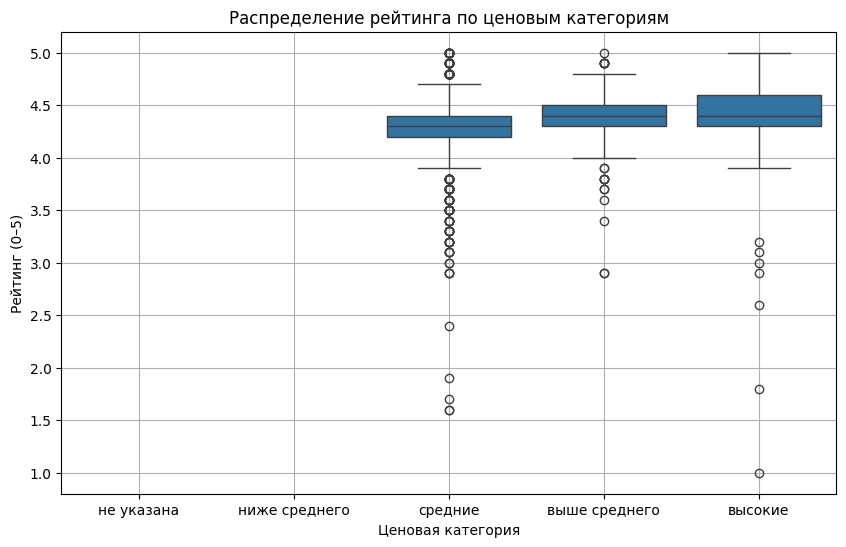

In [56]:

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='price', y='rating', order=[
    'не указана', 'ниже среднего', 'средние', 'выше среднего', 'высокие'
])
plt.title('Распределение рейтинга по ценовым категориям')
plt.xlabel('Ценовая категория')
plt.ylabel('Рейтинг (0–5)')

plt.grid()
plt.show()

**Выводы:**

- Наибольший средний рейтинг наблюдается в категории «выше среднего» и «высокие» цены - боксплоты расположены ближе к верхней части шкалы (около 4,5–5 баллов).

- Категория «средние» цены также демонстрирует относительно высокий рейтинг (около 4,3–4,5 балла), что говорит о хорошем балансе «цена–качество».

### 3.7. Задача 7

In [57]:
print("Топ-15 популярных сетей:")

# Создаем сводную таблицу
pivot_stats = pd.pivot_table(
    df,
    index=df['name'],
    aggfunc={
        'name': 'size',
        'rating': 'mean',
        'category': 'first'
    },
    values=['name', 'rating', 'category']
)

# Настраиваем оформление таблицы
pivot_stats.columns = ['category', 'count', 'avg_rating']
pivot_stats['avg_rating']=pivot_stats['avg_rating'].round(2)

# Сортируем данные
pivot_stats = pivot_stats.sort_values('count', ascending=False)

# Выводим результат
print(pivot_stats.head(15))

Топ-15 популярных сетей:
                                            category  count  avg_rating
name                                                                   
Кафе                                            кафе    188        3.88
Шоколадница                                  кофейня    120        4.18
Домино'с Пицца                              пиццерия     76        4.17
Додо Пицца                                  пиццерия     74        4.29
One Price Coffee                             кофейня     71        4.06
Яндекс Лавка                                ресторан     69        3.87
Cofix                                        кофейня     65        4.08
Prime                                       ресторан     50        4.12
Хинкальная                           быстрое питание     44        4.32
Шаурма                               быстрое питание     43        3.91
КОФЕПОРТ                                     кофейня     42        4.15
Кулинарная лавка братьев Караваевых    

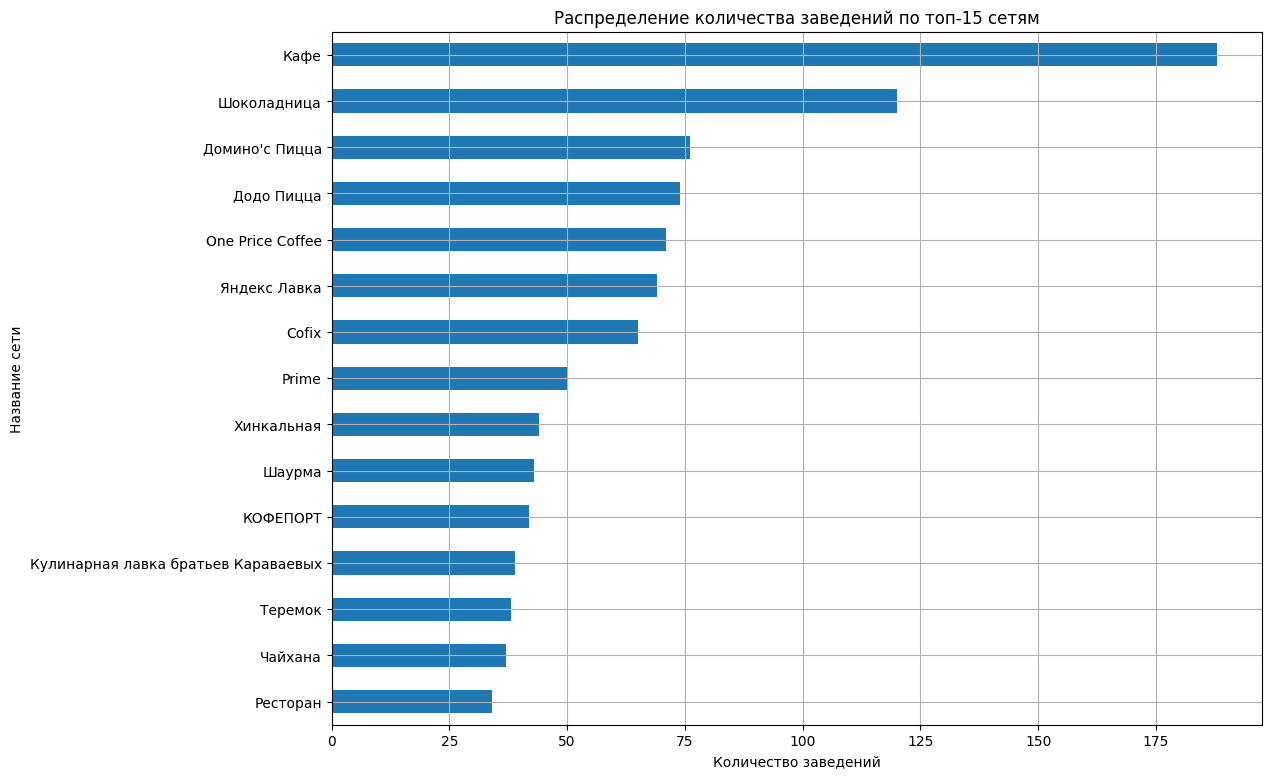

In [58]:
# Выбираем топ-15 популярных сетей
top_15 = pivot_stats.head(15)

# Задаем размер графика
plt.figure(figsize = (12, 9))

# Создаем столбчатую диаграмму
top_15['count'].sort_values(ascending=True).plot(
    kind='barh',
    rot=0,
    legend=False
)

# Настраиваем оформление графика
plt.title('Распределение количества заведений по топ-15 сетям')
plt.xlabel('Количество заведений')
plt.ylabel('Название сети')

# Добавляем сетку графика
plt.grid()

# Выводим визуализированные данные
plt.show()

**Вывод:**

- Сеть "Кафе" явно лидирует по количеству заведений (более 175)

- "Шоколадница" идёт второй с результатом между 100 и 125 заведениями

- На другом конце спектра "Ресторан" (менее 50) и "Чайхана" (между 25 и 50) имеют значительно меньше точек

### 3.8. Задача 8

In [59]:
# Группируем данные по административным округам и вычисляем средний чек для каждого из них.
mean_middle_avg_bill = df.groupby('district')['middle_avg_bill'].mean().sort_values(ascending=False).round(2)

print("Статистика среднего чека по административным округам:")
print(mean_middle_avg_bill)

Статистика среднего чека по административным округам:
district
Центральный административный округ         965.80
Западный административный округ            806.40
Северо-Западный административный округ     744.59
Северный административный округ            737.34
Южный административный округ               736.44
Юго-Западный административный округ        705.93
Восточный административный округ           704.53
Северо-Восточный административный округ    673.90
Юго-Восточный административный округ       662.81
Name: middle_avg_bill, dtype: float64


C:\Users\Huawei\AppData\Local\Temp\ipykernel_12416\3323866731.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_middle_avg_bill = df.groupby('district')['middle_avg_bill'].mean().sort_values(ascending=False).round(2)


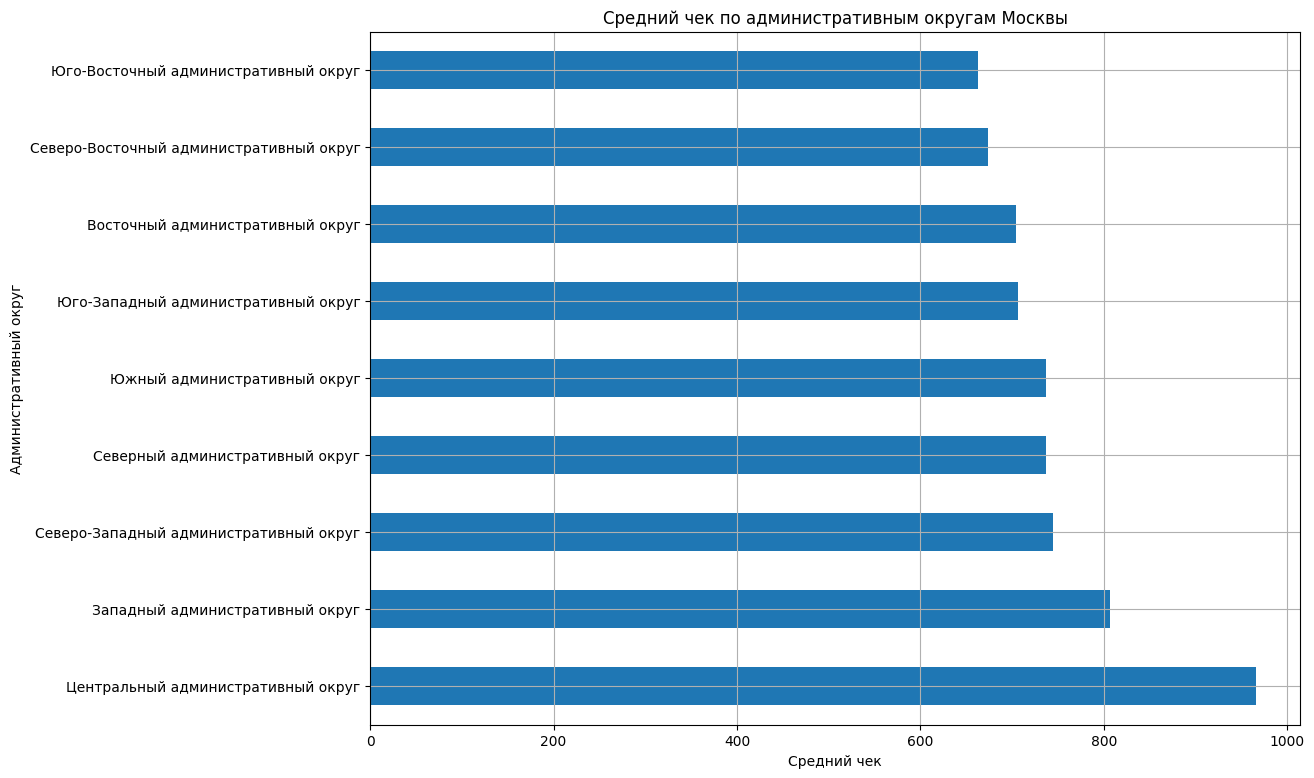

In [60]:
# Задаем размер графика
plt.figure(figsize = (12, 9))

# Создаем столбчатую диаграмму
mean_middle_avg_bill.plot(
    kind='barh',
    rot=0,
    legend=False
)

# Настраиваем оформление осей
plt.title('Средний чек по административным округам Москвы')
plt.xlabel('Средний чек')
plt.ylabel('Административный округ')

# Добавляем сетку графика
plt.grid()

# Выводим визуализированные данные
plt.show()

**Вывод:**

- Максимальный средний чек наблюдается в Центральном административном округе

- Минимальный средний чек наблюдается в Юго-Восточном административном округе

In [61]:
# Создаем датафреймы для центрального и нецентральных округов
central_bills = df[df['district'] == 'Центральный административный округ']
other_bills = df[df['district'] != 'Центральный административный округ']

# Посчитаем средний чек для каждой группы
central_avg_bill = central_bills['middle_avg_bill'].mean()
other_avg_bill = other_bills['middle_avg_bill'].mean()

# Создаем датафрейм для визуализации
df_district = pd.DataFrame({
    'Округ': ['Центральный', 'Нецентральный'],
    'Средний чек': [central_avg_bill, other_avg_bill]
})

In [62]:
df_district.round(2)

,Округ,Средний чек
0,Центральный,965.80
1,Нецентральный,721.55


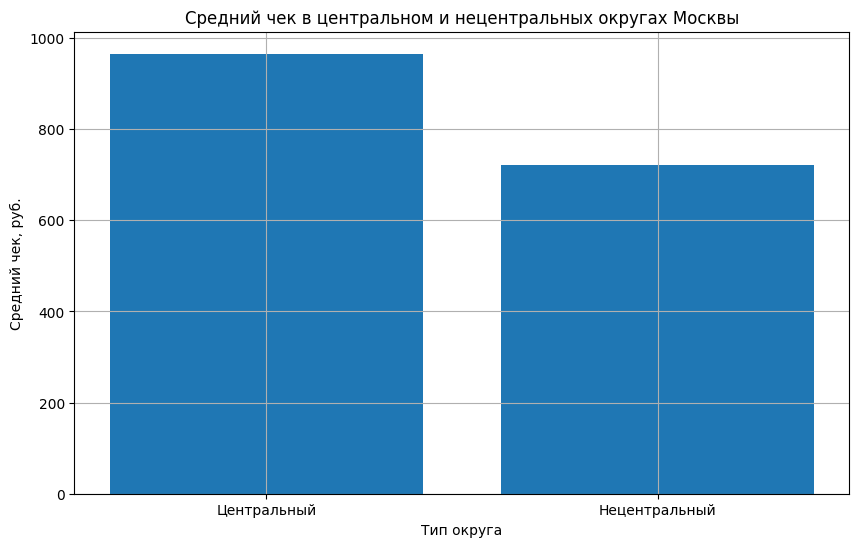

In [63]:
# Задаем размер графика
plt.figure(figsize=(10, 6))

# Создаем столбчатую диаграмму
plt.bar(df_district['Округ'], 
        df_district['Средний чек'])

# Настраиваем оформление графиков
plt.xlabel('Тип округа')
plt.ylabel('Средний чек, руб.')
plt.title('Средний чек в центральном и нецентральных округах Москвы')

# Добавляем сетку графика
plt.grid()

# Выводим визуализированные данные
plt.show()

**Вывод:**

- В Центральном административном округе средний чек выше, чем в других округах.

### 3.9. Промежуточный вывод

- По количеству заведений лидируют кафе (2378) и рестораны (1413), что делает эти сегменты наиболее конкурентными. Наименьшее число объектов наблюдается среди булочных (256) и столовых (315), что может указывать на их меньшую популярность или специфичность формата.

- Наиболее высокий средний чек фиксируется в заведениях Центрального административного округа. Он примерно на 200–230 рублей (30–35%) выше, чем медианные значения в других округах. Это подтверждает ожидаемое влияние центральной локации на ценовую политику.

- Количество посадочных мест и сетевая принадлежность также оказывают статистически значимое, но менее выраженное влияние на средний чек по сравнению с округом и категорией.

## 4. Итоговый вывод и рекомендации

В ходе исследования был проведён анализ данных о заведениях общественного питания Москвы, включающий информацию об их названии, категории, административном округе, рейтинге, сетевой принадлежности, количестве посадочных мест и среднем чеке.

### Фокус был сделан на изучении:

- распределения посадочных мест по категориям заведений

- наличия и природы аномальных значений (выбросов)

- географических особенностей рынка

- вариативности размеров заведений в зависимости от типа

### Общий профиль рынка общепита Москвы:

Анализ позволил сформировать ключевые характеристики рынка:

- Наиболее распространённые форматы — кафе (2378 заведений) и рестораны (1413), что делает эти сегменты наиболее конкурентными.

- Наименьшее число объектов — среди булочных (256) и столовых (315), что может указывать на их нишевую специализацию.

- Среднее количество посадочных мест варьируется от 72,77 (булочные) до 108,34 (рестораны).

- Во всех категориях медиана ниже среднего, что свидетельствует о наличии крупных заведений, искажающих средние показатели.

- Максимальный разброс значений наблюдается у баров/пабов (115,21) и ресторанов (99,11), что подтверждает неоднородность этих сегментов.

### Факторы, влияющие на ценообразование в заведениях

На уровень среднего чека положительно влияют несколько ключевых факторов: административный округ, категория заведения, а также его размер и сетевая принадлежность.

К более высоким ценам склонны:

- Заведения в Центральном административном округе - из-за высокой стоимости аренды

- Рестораны и бары, которые в среднем имеют более высокий чек, чем кафе, столовые или заведения быстрого питания

### Рекомендации

- Выбор оптимального размера (50-100 мест) и категории заведения должен основываться на глубоком анализе локальной конкуренции и платежеспособного спроса в конкретном районе, а не только на его удалённости от центра.

- Для более точного моделирования ценообразования рекомендуется провести углублённый анализ с учётом взаимодействия факторов